# Imports

In [1]:
import numpy as np
import pandas as pd
import os
!pip install monai

import matplotlib.pyplot as plt
import seaborn as sns
import os
import nibabel as nib
from sklearn.model_selection import StratifiedGroupKFold
import torch
from torch.utils.data import Dataset, DataLoader
import torch
import torch.nn as nn
import numpy as np
import timm
from transformers import Adafactor


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 75.0 MB/s eta 0:00:00:00:01


# EDA

In [2]:
import pandas as pd
import numpy as np

print("Loading Parquet file...")
df = pd.read_parquet('/kaggle/input/lidc-lung-nodule-classification/train.parquet')

print(f"Dataset shape: {df.shape}")

unique_counts = {}
for col in df.columns:
    try:
        unique_counts[col] = df[col].nunique()
    except TypeError:
        unique_counts[col] = "Unhashable (dict/list)"

df_info = pd.DataFrame({
    'Type': df.dtypes,
    'Missing Values': df.isnull().sum(),
    'Unique Values': pd.Series(unique_counts)
})

print("\n--- Column Info ---")
print(df_info)

print("\n--- First Row Data (Deep Dive) ---")
first_row = df.iloc[0].to_dict()
for key, value in first_row.items():
    if isinstance(value, (list, dict, np.ndarray)) or (hasattr(value, '__len__') and len(str(value)) > 200):
        try:
            print(f"{key}: {type(value)} | Length/Shape: {len(value)}")
        except:
            print(f"{key}: {type(value)} | Too large to display")
    else:
        print(f"{key}: {value}")

Loading Parquet file...
Dataset shape: (1986, 10)

--- Column Info ---
               Type  Missing Values           Unique Values
id           object               0                    1986
image_id     object               0                     680
object_id     int64               0                      21
patient_id   object               0                     680
series_name  object               0                     680
study_id     object               0                     680
segmentMap   object               0  Unhashable (dict/list)
bbox         object               0  Unhashable (dict/list)
label        object               0                       5
label_id      int64               0                       5

--- First Row Data (Deep Dive) ---
id: 30930.000000-Recon 2 LOW DOSE THROUGH LUNGS-19490__1
image_id: 30930.000000-Recon 2 LOW DOSE THROUGH LUNGS-19490
object_id: 1
patient_id: LIDC-IDRI-0939
series_name: 1.3.6.1.4.1.14519.5.2.1.6279.6001.31383599672536434203483011949

In [3]:
print("--- Class Distribution ---")
print(df['label'].value_counts(dropna=False))

print("\n--- segmentMap Keys ---")
first_segment_map = df.iloc[0]['segmentMap']
if isinstance(first_segment_map, dict):
    for k, v in first_segment_map.items():
        if isinstance(v, (list, dict, np.ndarray)) or (hasattr(v, '__len__') and len(str(v)) > 100):
            print(f"Key: {k} | Type: {type(v)} | Length: {len(v)}")
        else:
            print(f"Key: {k} | Value: {v}")
else:
    print("segmentMap is not a dict. Type:", type(first_segment_map))

--- Class Distribution ---
label
Indeterminate            918
Moderately Unlikely      418
Moderately Suspicious    269
Highly Unlikely          250
Highly Suspicious        131
Name: count, dtype: int64

--- segmentMap Keys ---
Key: 1 | Value: None
Key: Calcification | Type: <class 'numpy.ndarray'> | Length: 1
Key: InternalStructure | Type: <class 'numpy.ndarray'> | Length: 1
Key: Lobulation | Type: <class 'numpy.ndarray'> | Length: 1
Key: Malignancy | Type: <class 'numpy.ndarray'> | Length: 1
Key: Margin | Type: <class 'numpy.ndarray'> | Length: 1
Key: Sphericity | Type: <class 'numpy.ndarray'> | Length: 1
Key: Spiculation | Type: <class 'numpy.ndarray'> | Length: 1
Key: Subtlety | Type: <class 'numpy.ndarray'> | Length: 1
Key: Texture | Type: <class 'numpy.ndarray'> | Length: 1


Looking for file: /kaggle/input/datasets/vladimirsydor/lidc-classification-ct-scans/32113.000000-Recon 2 ACRIN LARGE-45498.nii
Original 3D scan shape: (512, 512, 506)
Original Bbox coordinates: [150 309 253 162 321 260]
Context patch shape: (64, 64, 16)


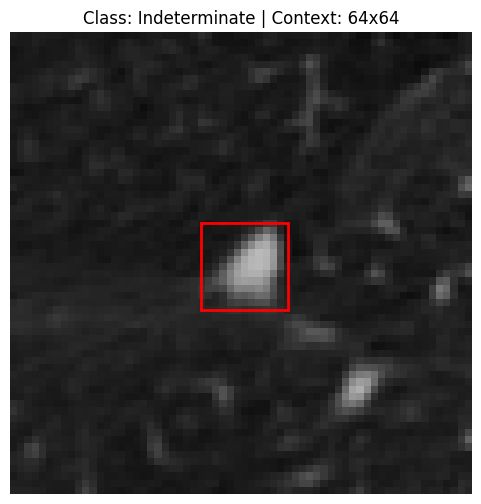

In [4]:
CT_SCANS_DIR = '/kaggle/input/datasets/vladimirsydor/lidc-classification-ct-scans/'

row = df.iloc[55]
image_id = row['image_id']
bbox = row['bbox']

file_path = os.path.join(CT_SCANS_DIR, f"{image_id}.nii")
print(f"Looking for file: {file_path}")

if os.path.exists(file_path):
    nii_img = nib.load(file_path)
    scan_data = nii_img.get_fdata()
    print(f"Original 3D scan shape: {scan_data.shape}")
    print(f"Original Bbox coordinates: {bbox}")
    
    try:
        x_min, y_min, z_min, x_max, y_max, z_max = map(int, bbox)
        
        c_x = (x_min + x_max) // 2
        c_y = (y_min + y_max) // 2
        c_z = (z_min + z_max) // 2
        
        patch_size_xy = 64
        patch_size_z = 16
        
        x_start = max(0, c_x - patch_size_xy // 2)
        x_end = min(scan_data.shape[0], c_x + patch_size_xy // 2)
        y_start = max(0, c_y - patch_size_xy // 2)
        y_end = min(scan_data.shape[1], c_y + patch_size_xy // 2)
        z_start = max(0, c_z - patch_size_z // 2)
        z_end = min(scan_data.shape[2], c_z + patch_size_z // 2)
        
        patch = scan_data[x_start:x_end, y_start:y_end, z_start:z_end]
        print(f"Context patch shape: {patch.shape}")
        
        if patch.size > 0:
            center_z_patch = patch.shape[2] // 2
            
            plt.figure(figsize=(6, 6))
            plt.imshow(patch[:, :, center_z_patch].T, cmap='gray', vmin=-1000, vmax=400)
            
            plt.gca().add_patch(plt.Rectangle((patch_size_xy//2 - (x_max-x_min)//2, 
                                               patch_size_xy//2 - (y_max-y_min)//2), 
                                              (x_max-x_min), (y_max-y_min), 
                                              edgecolor='red', facecolor='none', lw=2))
            
            plt.title(f"Class: {row['label']} | Context: {patch_size_xy}x{patch_size_xy}")
            plt.axis('off')
            plt.show()
        else:
            print("Error: Empty patch.")
            
    except Exception as e:
        print(f"Error during cropping: {e}")
else:
    print("File not found. Check the directory path!")

# Folds

In [5]:
print("Loading dataset for splitting...")
df = pd.read_parquet('/kaggle/input/lidc-lung-nodule-classification/train.parquet')

n_splits = 5
sgkf = StratifiedGroupKFold(n_splits=n_splits, shuffle=True, random_state=42)

df['fold'] = -1

for fold, (train_idx, val_idx) in enumerate(sgkf.split(X=df, y=df['label_id'], groups=df['patient_id'])):
    df.loc[val_idx, 'fold'] = fold

print("\n--- Fold Verification ---")
for fold in range(n_splits):
    val_df = df[df['fold'] == fold]
    train_df = df[df['fold'] != fold]
    
    val_patients = set(val_df['patient_id'])
    train_patients = set(train_df['patient_id'])
    leakage = val_patients.intersection(train_patients)
    
    print(f"\n[Fold {fold}]")
    print(f"Validation Samples: {len(val_df)} | Training Samples: {len(train_df)}")
    print(f"Validation Patients: {len(val_patients)} | Training Patients: {len(train_patients)}")
    print(f"Data Leakage (Shared Patients): {len(leakage)} {'(OK!)' if len(leakage) == 0 else '(WARNING!)'}")
    
    print("Class Distribution (Validation):")
    dist = val_df['label'].value_counts(normalize=True).round(3) * 100
    for label, pct in dist.items():
        print(f"  - {label}: {pct:.1f}%")

output_path = 'train_folds.csv'
df.to_csv(output_path, index=False)
print(f"\nSuccess! Prepared data saved to '{output_path}'.")

Loading dataset for splitting...

--- Fold Verification ---

[Fold 0]
Validation Samples: 382 | Training Samples: 1604
Validation Patients: 136 | Training Patients: 544
Data Leakage (Shared Patients): 0 (OK!)
Class Distribution (Validation):
  - Indeterminate: 49.7%
  - Moderately Unlikely: 19.6%
  - Moderately Suspicious: 12.6%
  - Highly Unlikely: 11.0%
  - Highly Suspicious: 7.1%

[Fold 1]
Validation Samples: 388 | Training Samples: 1598
Validation Patients: 140 | Training Patients: 540
Data Leakage (Shared Patients): 0 (OK!)
Class Distribution (Validation):
  - Indeterminate: 44.6%
  - Moderately Unlikely: 19.1%
  - Moderately Suspicious: 16.0%
  - Highly Unlikely: 13.4%
  - Highly Suspicious: 7.0%

[Fold 2]
Validation Samples: 415 | Training Samples: 1571
Validation Patients: 134 | Training Patients: 546
Data Leakage (Shared Patients): 0 (OK!)
Class Distribution (Validation):
  - Indeterminate: 45.8%
  - Moderately Unlikely: 22.7%
  - Highly Unlikely: 14.0%
  - Moderately Suspicio

# Dataset

In [6]:
class LIDCDataset(Dataset):
    def __init__(self, df, data_dir, patch_size=64, patch_size_z=16, is_train=True, transform=None):
        self.df = df.reset_index(drop=True)
        self.data_dir = data_dir
        self.patch_size = patch_size
        self.is_train = is_train
        self.transform = transform
        self.patch_size_z = patch_size_z
        
        self.hu_min = -1000.0
        self.hu_max = 400.0

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image_id = row['image_id']
        label = row['label_id']
        bbox = row['bbox']
        
        if isinstance(bbox, str):
            bbox_cleaned = bbox.strip('[]').replace(',', ' ').split()
        else:
            bbox_cleaned = bbox
            
        x_min, y_min, z_min, x_max, y_max, z_max = map(int, bbox_cleaned)
        
        file_path = os.path.join(self.data_dir, f"{image_id}.nii")
        nii_img = nib.load(file_path)
        scan_proxy = nii_img.dataobj 
        shape = nii_img.shape
        
        c_x = (x_min + x_max) // 2
        c_y = (y_min + y_max) // 2
        c_z = (z_min + z_max) // 2
        
        half_patch = self.patch_size // 2
        half_patch_z = self.patch_size_z // 2
        
        x_start = max(0, c_x - half_patch)
        x_end = min(shape[0], c_x + half_patch)
        y_start = max(0, c_y - half_patch)
        y_end = min(shape[1], c_y + half_patch)
        z_start = max(0, c_z - half_patch_z)
        z_end = min(shape[2], c_z + half_patch_z)
        
    
        patch_3d = np.array(scan_proxy[x_start:x_end, y_start:y_end, z_start:z_end])
      
        if patch_3d.shape != (self.patch_size, self.patch_size, self.patch_size_z):
            pad_x = self.patch_size - patch_3d.shape[0]
            pad_y = self.patch_size - patch_3d.shape[1]
            pad_z = self.patch_size_z - patch_3d.shape[2]
            patch_3d = np.pad(patch_3d, ((0, pad_x), (0, pad_y), (0, pad_z)), mode='constant', constant_values=self.hu_min)
            
        image = np.clip(patch_3d, self.hu_min, self.hu_max)
        image = (image - self.hu_min) / (self.hu_max - self.hu_min)
        image = image.astype(np.float32)
        
        # Add channel dimension so shape is (1, H, W, D) -> Permute to (C, D, H, W) which 3D CNNs expect
        image = torch.tensor(image).unsqueeze(0).permute(0, 3, 1, 2)
        
        if self.transform:
            image = self.transform(image) # Apply MONAI transforms
            
        return image, torch.tensor(label, dtype=torch.long)
        
        

if __name__ == '__main__':
    print("Testing Optimized LIDCDataset...")
    df_folds = pd.read_csv('train_folds.csv')
    CT_SCANS_DIR = '/kaggle/input/datasets/vladimirsydor/lidc-classification-ct-scans/'
    
    val_df = df_folds[df_folds['fold'] == 0]
    val_dataset = LIDCDataset(df=val_df, data_dir=CT_SCANS_DIR, patch_size=64, is_train=False)
    
    img_tensor, label_tensor = val_dataset[0]
    
    print("Success!")
    print(f"Tensor shape: {img_tensor.shape}")
    print(f"Label: {label_tensor.item()}")
    print(f"Min value: {img_tensor.min():.2f}, Max value: {img_tensor.max():.2f}")

Testing Optimized LIDCDataset...
Success!
Tensor shape: torch.Size([1, 16, 64, 64])
Label: -1
Min value: 0.00, Max value: 1.00


# ConvNeXt (Supervised)

In [7]:
from kaggle_secrets import UserSecretsClient
user_secrets = UserSecretsClient()
wandb_api = user_secrets.get_secret("wand_api_key")


In [8]:
!git clone https://github.com/MIC-DKFZ/MedNeXt.git mednext_repo
%cd mednext_repo
!pip install -e .
%cd ..

Cloning into 'mednext_repo'...
remote: Enumerating objects: 762, done.
remote: Counting objects: 100% (320/320), done.
remote: Compressing objects: 100% (76/76), done.
remote: Total 762 (delta 270), reused 244 (delta 244), pack-reused 442 (from 1)
Receiving objects: 100% (762/762), 522.43 KiB | 5.02 MiB/s, done.
Resolving deltas: 100% (459/459), done.
/kaggle/working/mednext_repo
Obtaining file:///kaggle/working/mednext_repo
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 156.3/156.3 kB 11.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.0/77.0 kB 8.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.3/13.3 MB 33.5 MB/s eta 0:00:0000:01:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 96.4/96.4 kB 8.7 MB/s eta 0:00:00
  Created wheel for batchgenerators: file

In [9]:
import os 
import sys
sys.path.append(os.path.abspath('mednext_repo'))
from nnunet_mednext import create_mednext_v1

In [11]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
import monai
import pandas as pd
import numpy as np
import wandb
import timm
from transformers import Adafactor
from torch.optim.lr_scheduler import CosineAnnealingLR
from tqdm import tqdm
import albumentations as A
from sklearn.metrics import f1_score 
import monai.transforms as mt
wandb.login(key=wandb_api)

try:
    N_EPOCHS = 5
    NAME = "mednext_small_3D_folds"
    DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
    N_FOLDS = 5

    class_counts = torch.tensor([918, 250, 418, 269, 131], dtype=torch.float32)
    class_weights = class_counts.sum() / (len(class_counts) * class_counts)
    class_weights = class_weights.to(DEVICE)

    train_tfms = mt.Compose([
        mt.RandFlip(prob=0.5, spatial_axis=0), #Hor
        mt.RandFlip(prob=0.5, spatial_axis=1), #Vert
        mt.RandFlip(prob=0.5, spatial_axis=2), #Depth
        mt.RandRotate90(prob=0.5, spatial_axes=(1, 2)),
        mt.RandGaussianNoise(prob=0.15, std=0.05)])
    val_tfms = None 

    df_folds = pd.read_csv('train_folds.csv')
    
    for fold in range(N_FOLDS):
        print(f"\n{'='*40}")
        print(f"========== STARTING FOLD {fold} ==========")
        print(f"{'='*40}\n")
        
        wandb.init(project="CV_ASS2", name=f"{NAME}_fold{fold}", reinit=True)

        train_df = df_folds[df_folds['fold'] != fold]
        val_df = df_folds[df_folds['fold'] == fold]

        train_dataset = LIDCDataset(df=train_df, data_dir=CT_SCANS_DIR, patch_size=64, is_train=True, transform=train_tfms)
        val_dataset = LIDCDataset(df=val_df, data_dir=CT_SCANS_DIR, patch_size=64, is_train=False, transform=val_tfms)
        
        train_loader = DataLoader(train_dataset, batch_size=8, num_workers=4, shuffle=True, pin_memory=True)
        val_loader = DataLoader(val_dataset, batch_size=8, num_workers=4, shuffle=False, pin_memory=True)

        model = create_mednext_v1(
            num_input_channels=1, 
            num_classes=5, 
            model_id='S',        
            kernel_size=5,       
            deep_supervision=False
        ).to(DEVICE)


        criterion = nn.CrossEntropyLoss(weight=class_weights)
        optimizer = Adafactor(model.parameters(), lr=1e-4, scale_parameter=False, relative_step=False, warmup_init=False)
        scheduler = CosineAnnealingLR(optimizer, T_max=N_EPOCHS * len(train_loader), eta_min=1e-5)

        best_val_f1 = 0.0 

        for epoch in range(N_EPOCHS):
            print(f"\nFold {fold} | Epoch {epoch+1}/{N_EPOCHS}")
            
            model.train()
            train_loss = 0.0
            
            for x, y in tqdm(train_loader, desc=f"Training F{fold}"):
                x, y = x.to(DEVICE), y.to(DEVICE)
                y = y + 1 
                
                optimizer.zero_grad()
                logits = model(x)
                logits = logits.mean(dim=(2, 3, 4)) 
                loss = criterion(logits, y)
                
                loss.backward()
                optimizer.step()
                scheduler.step()
                
                train_loss += loss.item()

            avg_train_loss = train_loss / len(train_loader)

            model.eval()
            val_loss = 0.0
            correct, total = 0, 0

            all_preds = []
            all_targets = []
            
            with torch.no_grad():
                for x, y in tqdm(val_loader, desc=f"Validating F{fold}"):
                    x, y = x.to(DEVICE), y.to(DEVICE)
                    y = y + 1 
                    
                    logits = model(x)
                    logits = logits.mean(dim=(2, 3, 4)) 
                
                    loss = criterion(logits, y)
                    val_loss += loss.item()
                    
                    preds = torch.argmax(logits, dim=1)
                    correct += (preds == y).sum().item()
                    total += y.size(0)
                    
                    all_preds.extend(preds.cpu().numpy())
                    all_targets.extend(y.cpu().numpy())

            avg_val_loss = val_loss / len(val_loader)
            val_acc = correct / total
            
            val_macro_f1 = f1_score(all_targets, all_preds, average='macro')

            wandb.log({
                "train_loss": avg_train_loss, 
                "val_loss": avg_val_loss, 
                "val_accuracy": val_acc, 
                "val_macro_f1": val_macro_f1,
                "lr": scheduler.get_last_lr()[0]
            })
            
            print(f"Fold {fold} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | Val Acc: {val_acc:.4f} | Val Macro F1: {val_macro_f1:.4f}")

            if val_macro_f1 > best_val_f1:
                best_val_f1 = val_macro_f1
                save_path = f"{NAME}_fold{fold}_best_model.pth"
                torch.save(model.state_dict(), save_path)
                print(f">>> Saved new best model for Fold {fold} to {save_path}!")

        wandb.finish()

except Exception as e:
    print(f"Training interrupted: {e}")
finally:
    if wandb.run is not None:
        wandb.finish()

wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: WARNING [wandb.login()] Changing session credentials to explicit value for https://api.wandb.ai.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc



========== STARTING FOLD 0 ==========




Fold 0 | Epoch 1/5


Validating F0: 100%|██████████| 48/48 [00:06<00:00,  7.47it/s]


Fold 0 | Train Loss: 1.6144 | Val Loss: 1.6151 | Val Acc: 0.3115 | Val Macro F1: 0.1801
>>> Saved new best model for Fold 0 to mednext_small_3D_folds_fold0_best_model.pth!

Fold 0 | Epoch 2/5


...

Validating F4: 100%|██████████| 45/45 [00:05<00:00,  7.61it/s]


Fold 4 | Train Loss: 1.4203 | Val Loss: 1.4511 | Val Acc: 0.3056 | Val Macro F1: 0.2639
>>> Saved new best model for Fold 4 to mednext_small_3D_folds_fold4_best_model.pth!

Fold 4 | Epoch 5/5


Validating F4: 100%|██████████| 45/45 [00:05<00:00,  7.76it/s]


Fold 4 | Train Loss: 1.4012 | Val Loss: 1.4270 | Val Acc: 0.3167 | Val Macro F1: 0.2815
>>> Saved new best model for Fold 4 to mednext_small_3D_folds_fold4_best_model.pth!


lr,█▆▄▂▁
train_loss,█▆▃▂▁
val_accuracy,▁▇▅▇█
val_loss,█▄▃▂▁
val_macro_f1,▁▅▄▇█
lr,1e-05
train_loss,1.40119
val_accuracy,0.31667
val_loss,1.42702
val_macro_f1,0.28146


In [13]:
import torch
from torch.utils.data import Dataset, DataLoader
import pandas as pd
import numpy as np
import os
import nibabel as nib
from tqdm import tqdm

import sys
if os.path.abspath('mednext_repo') not in sys.path:
    sys.path.append(os.path.abspath('mednext_repo'))
from nnunet_mednext import create_mednext_v1

NAME = "mednext_small_3D_folds" 
N_FOLDS = 5
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
CT_SCANS_DIR = '/kaggle/input/datasets/vladimirsydor/lidc-classification-ct-scans/'
TEST_CSV_PATH = '/kaggle/input/lidc-lung-nodule-classification/test.csv' 

class LIDCTestDataset(Dataset):
    def __init__(self, df, data_dir, patch_size=64, patch_size_z=16):
        self.df = df.reset_index(drop=True)
        self.data_dir = data_dir
        self.patch_size = patch_size
        self.patch_size_z = patch_size_z
        self.hu_min = -1000.0
        self.hu_max = 400.0

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image_id = row['image_id']
        row_id = row['id'] 
        bbox = row['bbox']
        
        if isinstance(bbox, str):
            bbox_cleaned = bbox.strip('[]').replace(',', ' ').split()
        else:
            bbox_cleaned = bbox
            
        x_min, y_min, z_min, x_max, y_max, z_max = map(int, bbox_cleaned)
        
        file_path = os.path.join(self.data_dir, f"{image_id}.nii")
        nii_img = nib.load(file_path)
        scan_proxy = nii_img.dataobj 
        shape = nii_img.shape
        
        c_x = (x_min + x_max) // 2
        c_y = (y_min + y_max) // 2
        c_z = (z_min + z_max) // 2
        
        half_patch = self.patch_size // 2
        half_patch_z = self.patch_size_z // 2
        
        x_start = max(0, c_x - half_patch)
        x_end = min(shape[0], c_x + half_patch)
        y_start = max(0, c_y - half_patch)
        y_end = min(shape[1], c_y + half_patch)
        z_start = max(0, c_z - half_patch_z)
        z_end = min(shape[2], c_z + half_patch_z)
        
        patch_3d = np.array(scan_proxy[x_start:x_end, y_start:y_end, z_start:z_end])
        
        if patch_3d.shape != (self.patch_size, self.patch_size, self.patch_size_z):
            pad_x = self.patch_size - patch_3d.shape[0]
            pad_y = self.patch_size - patch_3d.shape[1]
            pad_z = self.patch_size_z - patch_3d.shape[2]
            patch_3d = np.pad(patch_3d, ((0, pad_x), (0, pad_y), (0, pad_z)), mode='constant', constant_values=self.hu_min)
            
        image = np.clip(patch_3d, self.hu_min, self.hu_max)
        image = (image - self.hu_min) / (self.hu_max - self.hu_min)
        image = image.astype(np.float32)
        
        image = torch.tensor(image).unsqueeze(0).permute(0, 3, 1, 2)
            
        return image, str(row_id)

def generate_submission():
    print("Loading test data...")
    test_df = pd.read_csv(TEST_CSV_PATH) 
    
    test_dataset = LIDCTestDataset(df=test_df, data_dir=CT_SCANS_DIR, patch_size=64, patch_size_z=16)
    test_loader = DataLoader(test_dataset, batch_size=8, num_workers=4, shuffle=False)

    print("Initializing models for ensembling...")
    models = []
    
    for fold in range(N_FOLDS):
        model_path = f"{NAME}_fold{fold}_best_model.pth"
        print(f"Loading weights from: {model_path}")
        
        model = create_mednext_v1(
            num_input_channels=1, 
            num_classes=5, 
            model_id='S',        
            kernel_size=5,       
            deep_supervision=False
        )
        model.load_state_dict(torch.load(model_path, map_location=DEVICE))
        model.to(DEVICE)
        model.eval()
        
        models.append(model)

    all_ids = []
    all_preds = []

    print("Starting ensemble inference...")
    with torch.no_grad():
        for images, row_ids in tqdm(test_loader, desc="Predicting"):
            images = images.to(DEVICE)
            
            ensemble_logits = torch.zeros((images.size(0), 5), device=DEVICE)
            
            for model in models:
                logits = model(images)
                logits = logits.mean(dim=(2, 3, 4))
                ensemble_logits += logits
            
            ensemble_logits /= N_FOLDS
            
            ensemble_logits[:, 0] = -float('inf')
            preds = torch.argmax(ensemble_logits, dim=1)
            
            preds = preds - 1
            
            all_preds.extend(preds.cpu().numpy())
            all_ids.extend(row_ids)

    submission_df = pd.DataFrame({
        'id': all_ids,
        'label_id': all_preds
    })
    
    submission_df.to_csv('submission.csv', index=False)
    print("\nSuccess! Saved to submission.csv")
    print(submission_df.head())

if __name__ == '__main__':
    generate_submission()

Loading test data...
Initializing models for ensembling...
Loading weights from: mednext_small_3D_folds_fold0_best_model.pth
Loading weights from: mednext_small_3D_folds_fold1_best_model.pth
Loading weights from: mednext_small_3D_folds_fold2_best_model.pth
Loading weights from: mednext_small_3D_folds_fold3_best_model.pth
Loading weights from: mednext_small_3D_folds_fold4_best_model.pth
Starting ensemble inference...


Predicting: 100%|██████████| 35/35 [00:21<00:00,  1.66it/s]


Success! Saved to submission.csv
                                          id  label_id
0                 3000025.000000-NA-58100__1         0
1            4.000000-Recon 3 C-A-P-68794__1         1
2            4.000000-Recon 3 C-A-P-68794__2         1
3  30906.000000-Recon 2 ACRIN LARGE-35112__4         1
4  30906.000000-Recon 2 ACRIN LARGE-35112__5         1
